# 🔗 Penggabungan Data DBpedia & Wikidata

Notebook ini menggabungkan dua file CSV:
- `DBpedia_oke.csv` → kolom: `athleteName`, `clubName`, `countryName`
- `Wikidata_oke.csv` → kolom: `athleteLabel`, `clubLabel`, `countryName`

**Langkah-langkah:**
1. Upload file CSV
2. Load & preview masing-masing file
3. Unifikasi nama kolom
4. Gabungkan & hapus duplikat
5. Eksplorasi data hasil gabungan
6. Simpan ke CSV baru

## 📁 Step 1 — Upload File CSV

In [2]:
from google.colab import files

print('Silakan upload DBpedia_oke.csv dan Wikidata_oke.csv')
uploaded = files.upload()
print('\nFile yang berhasil diupload:')
for fname in uploaded:
    print(f'  ✅ {fname}')

Silakan upload DBpedia_clean.csv dan Wikidata_no_URI.csv


Saving DBpedia_oke.csv to DBpedia_oke.csv

File yang berhasil diupload:
  ✅ DBpedia_oke.csv


## 📊 Step 2 — Load & Preview Masing-masing CSV

In [26]:
df_dbpedia  = pd.read_csv('DBpedia_oke.csv')
df_wikidata = pd.read_csv('Wikidata_oke.csv')

print('=== DBpedia_oke.csv ===')
print(f'Jumlah baris : {len(df_dbpedia)}')
print(f'Kolom        : {df_dbpedia.columns.tolist()}')
print()

print('=== Wikidata_oke.csv ===')
print(f'Jumlah baris : {len(df_wikidata)}')
print(f'Kolom        : {df_wikidata.columns.tolist()}')
print()

=== DBpedia_oke.csv ===
Jumlah baris : 1000
Kolom        : ['athleteName', 'clubName', 'countryName']

=== Wikidata_oke.csv ===
Jumlah baris : 1000
Kolom        : ['athleteName', 'clubName', 'countryName']



In [27]:
print('=== Wikidata_no_URI.csv ===')
print(f'Jumlah baris : {len(df_wikidata)}')
print(f'Kolom        : {df_wikidata.columns.tolist()}')
print()
df_wikidata.head()

=== Wikidata_no_URI.csv ===
Jumlah baris : 1000
Kolom        : ['athleteName', 'clubName', 'countryName']



,athleteName,clubName,countryName
0,Thibaut Courtois,Chelsea F.C.,Belgium
1,John Terry,Chelsea F.C.,United Kingdom
2,Antonio Rüdiger,Chelsea F.C.,Germany
3,Claudio Pizarro,Chelsea F.C.,Peru
4,Loïc Rémy,Chelsea F.C.,France


## 🔄 Step 3 — Tambah kolom sumber sebelum digabung

Kedua CSV punya nama kolom berbeda, kita samakan menjadi `athlete` dan `club`.

In [28]:
df_dbpedia['source']  = 'DBpedia'
df_wikidata['source'] = 'Wikidata'

## 🔗 Step 4 — Gabungkan & Hapus Duplikat

In [29]:
# ── 3. Gabungkan kedua dataframe ──────────────────────────────────────────────
df_combined = pd.concat([df_dbpedia, df_wikidata], ignore_index=True)
print(f'Total baris sebelum dedup : {len(df_combined)}')

# ── 4. Hapus baris dengan nilai kosong ────────────────────────────────────────
df_combined = df_combined.dropna(subset=['athleteName', 'clubName', 'countryName'])

# ── 5. Hapus duplikat ─────────────────────────────────────────────────────────
duplikat = df_combined.duplicated(subset=['athleteName', 'clubName', 'countryName']).sum()
print(f'Duplikat ditemukan        : {duplikat}')

df_combined = df_combined.drop_duplicates(subset=['athleteName', 'clubName'])
df_combined = df_combined.reset_index(drop=True)
print(f'Total baris setelah dedup : {len(df_combined)}')
print()


Total baris sebelum dedup : 2000
Duplikat ditemukan        : 121
Total baris setelah dedup : 1842



## 🔍 Step 5 — Ringkasan

In [30]:
print('=== Ringkasan Data ===')
print(f'Total relasi (atlet-klub) : {len(df_combined)}')
print(f'Atlet unik                : {df_combined["athleteName"].nunique()}')
print(f'Klub unik                 : {df_combined["clubName"].nunique()}')
print()

print('=== Distribusi per Sumber ===')
print(df_combined['source'].value_counts())
print()

print('=== Jumlah Atlet per Klub ===')
print(df_combined.groupby('clubName')['athleteName'].count().sort_values(ascending=False))
print()
print(df_combined.head(10))

=== Ringkasan Data ===
Total relasi (atlet-klub) : 1842
Atlet unik                : 1812
Klub unik                 : 3

=== Distribusi per Sumber ===
source
DBpedia     1000
Wikidata     842
Name: count, dtype: int64

=== Jumlah Atlet per Klub ===
clubName
Chelsea F.C.              816
Manchester United F.C.    628
Arsenal F.C.              398
Name: athleteName, dtype: int64

                             athleteName                clubName  \
0                          Nikita Haikin            Chelsea F.C.   
1                           Luke Freeman            Arsenal F.C.   
2                          Fraser Franks            Chelsea F.C.   
3  Fred Williams (footballer, born 1873)  Manchester United F.C.   
4   Alex Menzies (footballer, born 1882)  Manchester United F.C.   
5                            Allan Craig            Chelsea F.C.   
6                           Ken Nicholas            Arsenal F.C.   
7            Albert Jackson (footballer)  Manchester United F.C.   
8       

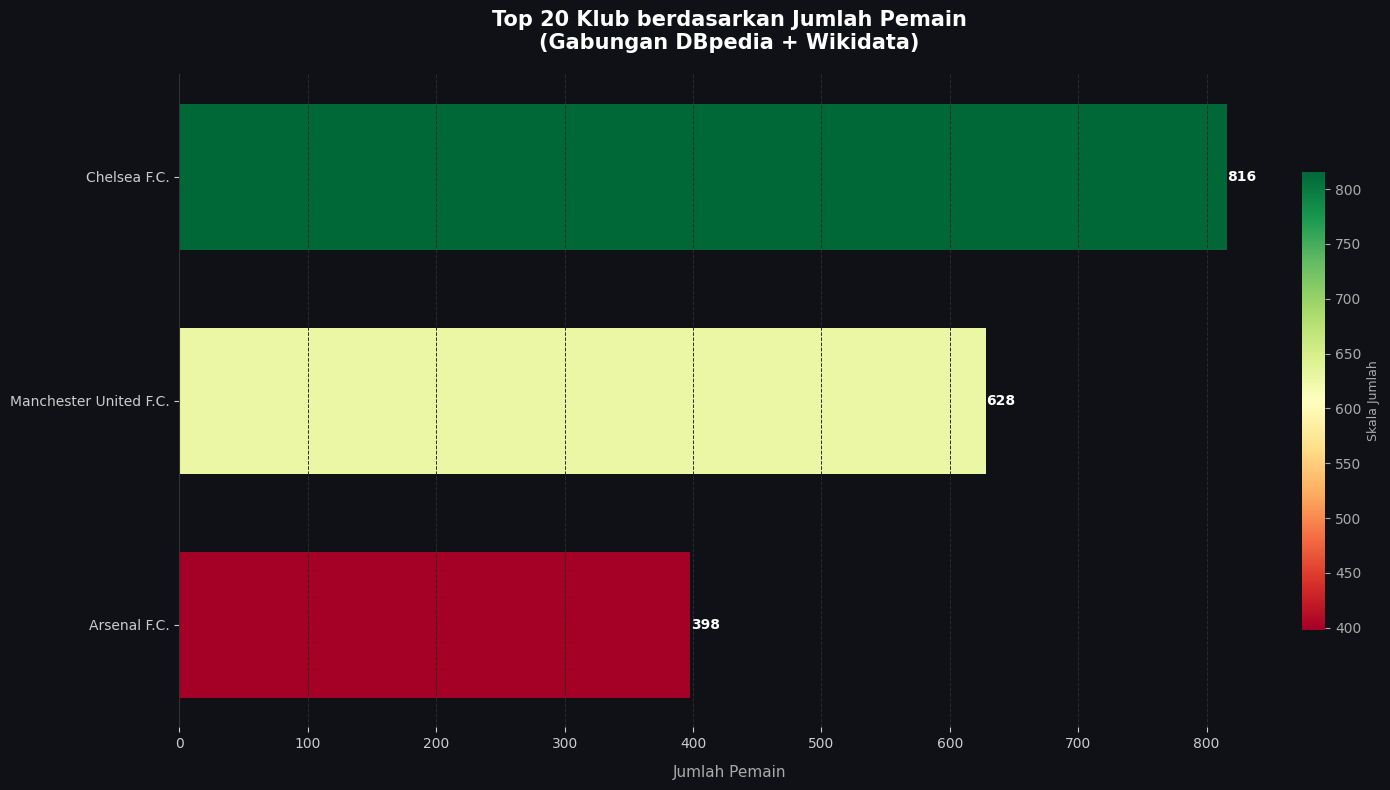


✅ Grafik disimpan sebagai top_clubs_chart.png

=== Semua Klub (urut terbanyak) ===
                  Club  Jumlah Pemain
          Chelsea F.C.            816
Manchester United F.C.            628
          Arsenal F.C.            398


In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# Hitung jumlah pemain per klub
club_counts = (
    df_combined.groupby('clubName')['athleteName']
    .nunique()
    .sort_values(ascending=False)
    .reset_index()
)
club_counts.columns = ['Club', 'Jumlah Pemain']

# ── Ambil Top 20 klub (agar grafik tidak terlalu padat) ───────────────────────
top_n = 20
df_plot = club_counts.head(top_n)

# ── Warna gradient berdasarkan nilai ─────────────────────────────────────────
norm   = plt.Normalize(df_plot['Jumlah Pemain'].min(), df_plot['Jumlah Pemain'].max())
colors = plt.cm.RdYlGn(norm(df_plot['Jumlah Pemain'].values))

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 8))
fig.patch.set_facecolor('#0f1117')
ax.set_facecolor('#0f1117')

bars = ax.barh(
    df_plot['Club'],
    df_plot['Jumlah Pemain'],
    color=colors,
    edgecolor='none',
    height=0.65
)

# Label nilai di ujung bar
for bar, val in zip(bars, df_plot['Jumlah Pemain']):
    ax.text(
        bar.get_width() + 0.15,
        bar.get_y() + bar.get_height() / 2,
        str(val),
        va='center', ha='left',
        color='white', fontsize=10, fontweight='bold'
    )

# Styling sumbu & judul
ax.invert_yaxis()
ax.set_xlabel('Jumlah Pemain', color='#aaaaaa', fontsize=11, labelpad=10)
ax.set_title(
    f'Top {top_n} Klub berdasarkan Jumlah Pemain\n(Gabungan DBpedia + Wikidata)',
    color='white', fontsize=15, fontweight='bold', pad=18
)

ax.tick_params(colors='#cccccc', labelsize=10)
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
for spine in ax.spines.values():
    spine.set_visible(False)
ax.axvline(0, color='#333333', linewidth=0.8)
ax.grid(axis='x', color='#2a2a2a', linewidth=0.7, linestyle='--')

# Colorbar legenda
sm = plt.cm.ScalarMappable(cmap='RdYlGn', norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, orientation='vertical', fraction=0.02, pad=0.02)
cbar.ax.yaxis.set_tick_params(color='#aaaaaa', labelcolor='#aaaaaa')
cbar.set_label('Skala Jumlah', color='#aaaaaa', fontsize=9)
cbar.outline.set_visible(False)

plt.tight_layout()
plt.savefig('top_clubs_chart.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print(f'\n✅ Grafik disimpan sebagai top_clubs_chart.png')
print(f'\n=== Semua Klub (urut terbanyak) ===')
print(club_counts.to_string(index=False))

## 💾 Step 6 — Simpan Hasil ke CSV

In [33]:
output_file = 'combined_athlete_club_oke.csv'
df_combined.to_csv(output_file, index=False)
print(f'\n✅ File berhasil disimpan: {output_file}')
print(f'   Total baris : {len(df_combined)}')
print(f'   Kolom       : {df_combined.columns.tolist()}')
print()
print(df_combined.head())


✅ File berhasil disimpan: combined_athlete_club_oke.csv
   Total baris : 1842
   Kolom       : ['athleteName', 'clubName', 'countryName', 'source']

                             athleteName                clubName  \
0                          Nikita Haikin            Chelsea F.C.   
1                           Luke Freeman            Arsenal F.C.   
2                          Fraser Franks            Chelsea F.C.   
3  Fred Williams (footballer, born 1873)  Manchester United F.C.   
4   Alex Menzies (footballer, born 1882)  Manchester United F.C.   

      countryName   source  
0          Israel  DBpedia  
1  United Kingdom  DBpedia  
2  United Kingdom  DBpedia  
3  United Kingdom  DBpedia  
4  United Kingdom  DBpedia  
